# Rubin-like galaxy-cluster lens with PCAT

A **synthetic**, single-band image of one cluster-scale, circular isothermal lens is simulated at 0.2 arcsec per pixel with 0.7 arcsec Gaussian seeing. The background galaxy is a smooth elliptical Gaussian. PCAT samples the cluster Einstein radius and the two source coordinates from a Poisson image likelihood. This is a controlled illustration, not Rubin Observatory data or a reconstruction of a real multi-halo cluster. The foreground galaxy light, neighboring cluster members, correlated sky noise, and PSF uncertainty are omitted.

In [1]:
from pathlib import Path

import numpy as np
import pcat
from pcat.roman_lens import RomanLensConfig, render_lens_counts, run_lens_image_pipeline

output_root = Path(pcat.__file__).resolve().parents[1] / 'examples/simulated_rubin_cluster_lens'
config = RomanLensConfig(
    number_side=160,
    pixel_scale=0.2,  # [arcsec pixel^-1]
    psf_fwhm=0.7,  # [arcsec]
    background=25.0,  # [electron pixel^-1]
    read_noise=0.0,  # [electron pixel^-1], for a Poisson-only mock
    source_counts=300_000.0,  # [electron]
)
source_size = 0.7  # [arcsec]
source_axis_ratio = 0.65
source_angle = 0.45  # [rad]
true_parameters = np.array([10.5, 0.7, 0.4])  # [arcsec] Einstein radius, source x, source y
random = np.random.default_rng(20260929)

expected_counts = render_lens_counts(
    config, true_parameters, source_size, source_axis_ratio, source_angle
)  # [electron pixel^-1]
observed_counts = random.poisson(expected_counts)  # [electron pixel^-1]
assert observed_counts.shape == (config.number_side, config.number_side)
print(f'Simulated {observed_counts.sum():,} detected electrons on {config.number_side} x {config.number_side} pixels.')

Simulated 940,021 detected electrons on 160 x 160 pixels.


## Fit the image

PCAT's generic fixed-dimensional sampler evaluates a Poisson likelihood on every pixel. The source size, shape, total brightness, sky background, and seeing are held at their injected values. These short chains demonstrate the workflow; inspect mixing and run longer chains before interpreting credible intervals.

In [2]:
typefileplot = 'png'  # choose 'png' or 'pdf'
pipeline = run_lens_image_pipeline(
    config=config,
    observed_counts=observed_counts,
    source_size=source_size,
    source_axis_ratio=source_axis_ratio,
    source_angle=source_angle,
    true_parameters=true_parameters,
    output_root=output_root,
    run_name='rubin_cluster_mock',
    visual_stem='rubin_cluster',
    typefileplot=typefileplot,
)
draws = pipeline.draws
median_parameters = pipeline.median_parameters
assert draws.shape[1] == 3 and np.all(np.isfinite(draws))
print(f'Posterior median Einstein radius: {median_parameters[0]:.2f} arcsec')

Setting the remaining few parameters in the reference model to those in the true model...
setp_paragenrscalbase(): Building the fitt model base paremeter names and scales...
gmod.numbparagenrbase
3
Determining the list of derived, fixed-dimensional parameter names...
gmod.namepara.genrelem
[]
Constructing arrays of parameter features such as minima, maxima, labels, scalings, etc...
Defining minima and maxima for derived parameters...
Reading from /Users/tdaylan/Documents/work/git/pcat/examples/simulated_rubin_cluster_lens/pcat_runs/rubin_cluster_mock/data/outp/rubin_cluster_mock/stat.txt...
Reading from /Users/tdaylan/Documents/work/git/pcat/examples/simulated_rubin_cluster_lens/pcat_runs/rubin_cluster_mock/data/outp/rubin_cluster_mock/gdatinit.p...
Reading /Users/tdaylan/Documents/work/git/pcat/examples/simulated_rubin_cluster_lens/pcat_runs/rubin_cluster_mock/data/outp/rubin_cluster_mock/gdatinit.h5...
Entering final post-processing stage (pdf: post, meaning posterior/final products)

Writing to /Users/tdaylan/Documents/work/git/pcat/examples/simulated_rubin_cluster_lens/visuals/rubin_cluster_posterior.png...
Posterior median Einstein radius: 10.50 arcsec


Reading from /Users/tdaylan/Documents/work/git/pcat/examples/simulated_rubin_cluster_lens/visuals/rubin_cluster_image_fit.png...


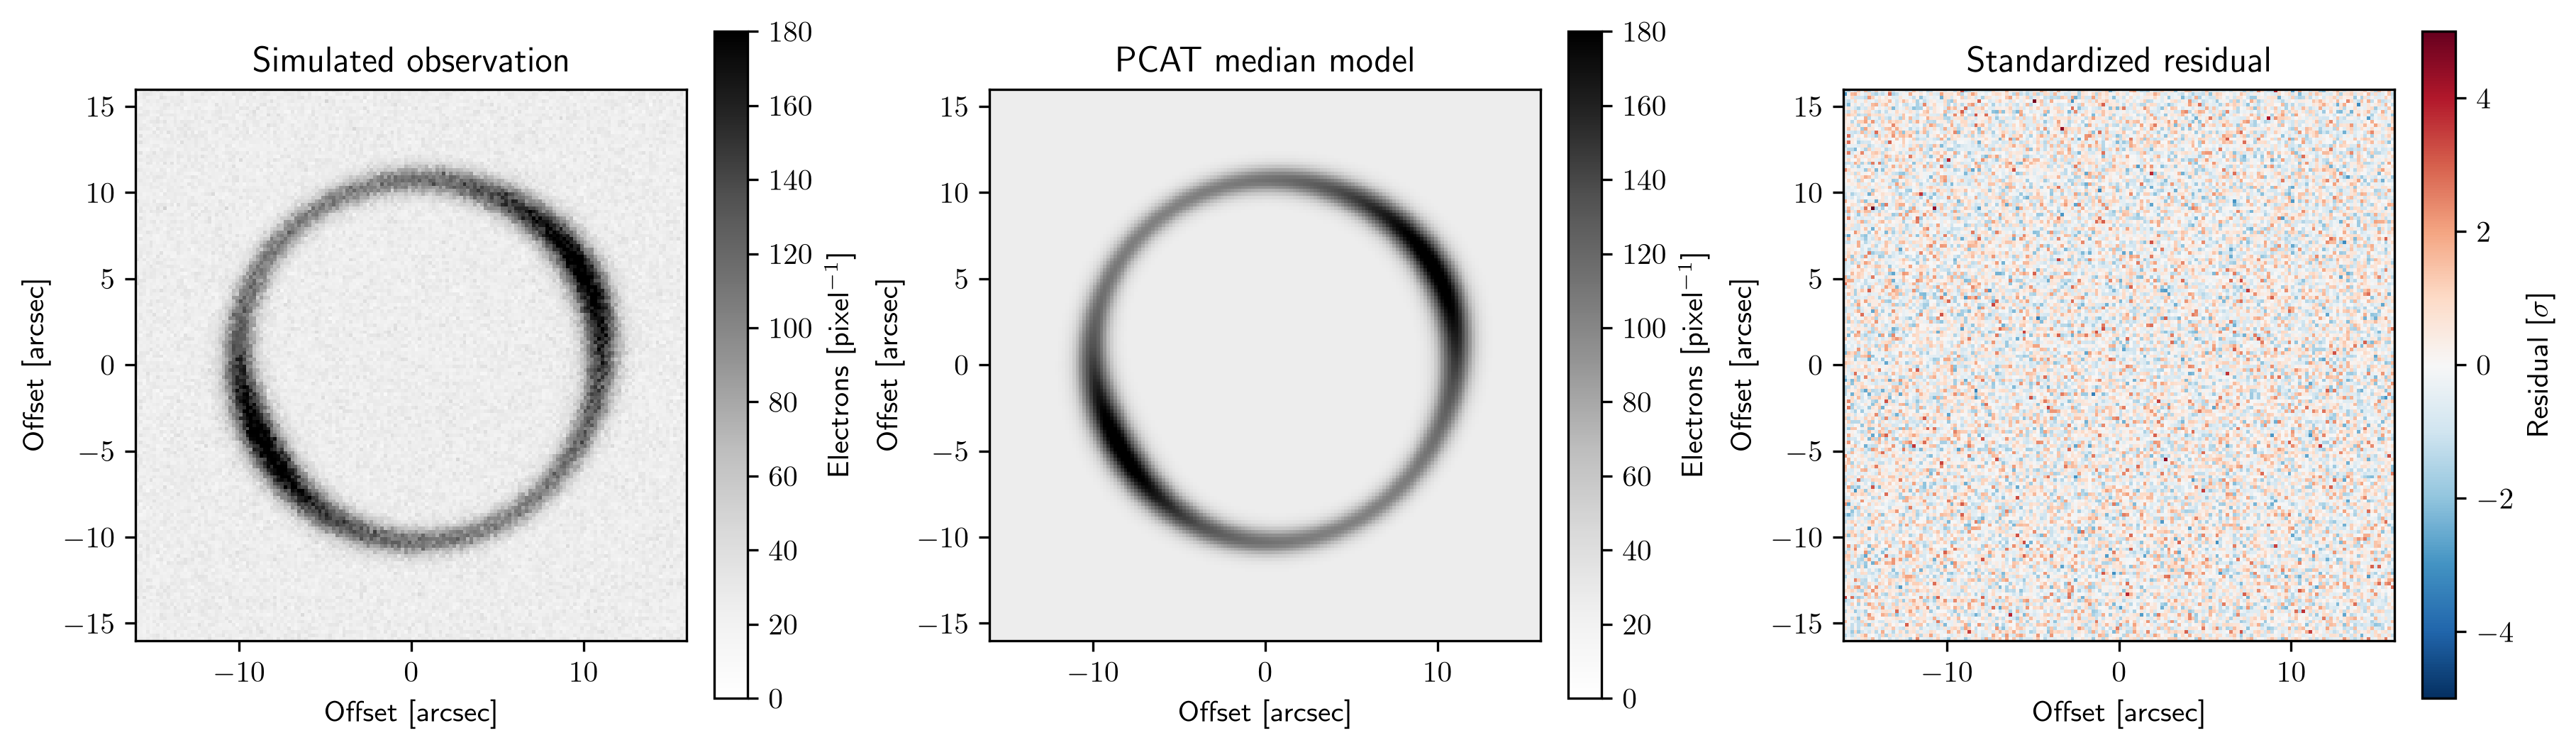

In [3]:
from IPython.display import Image, display

print(f'Reading from {pipeline.image_fit_path}...')
display(Image(filename=str(pipeline.image_fit_path)))

## Parameter recovery

The curves below summarize this finite PCAT chain, with the injected values shown for comparison. They are illustrative posterior marginals, not validated cluster constraints.

Reading from /Users/tdaylan/Documents/work/git/pcat/examples/simulated_rubin_cluster_lens/visuals/rubin_cluster_posterior.png...


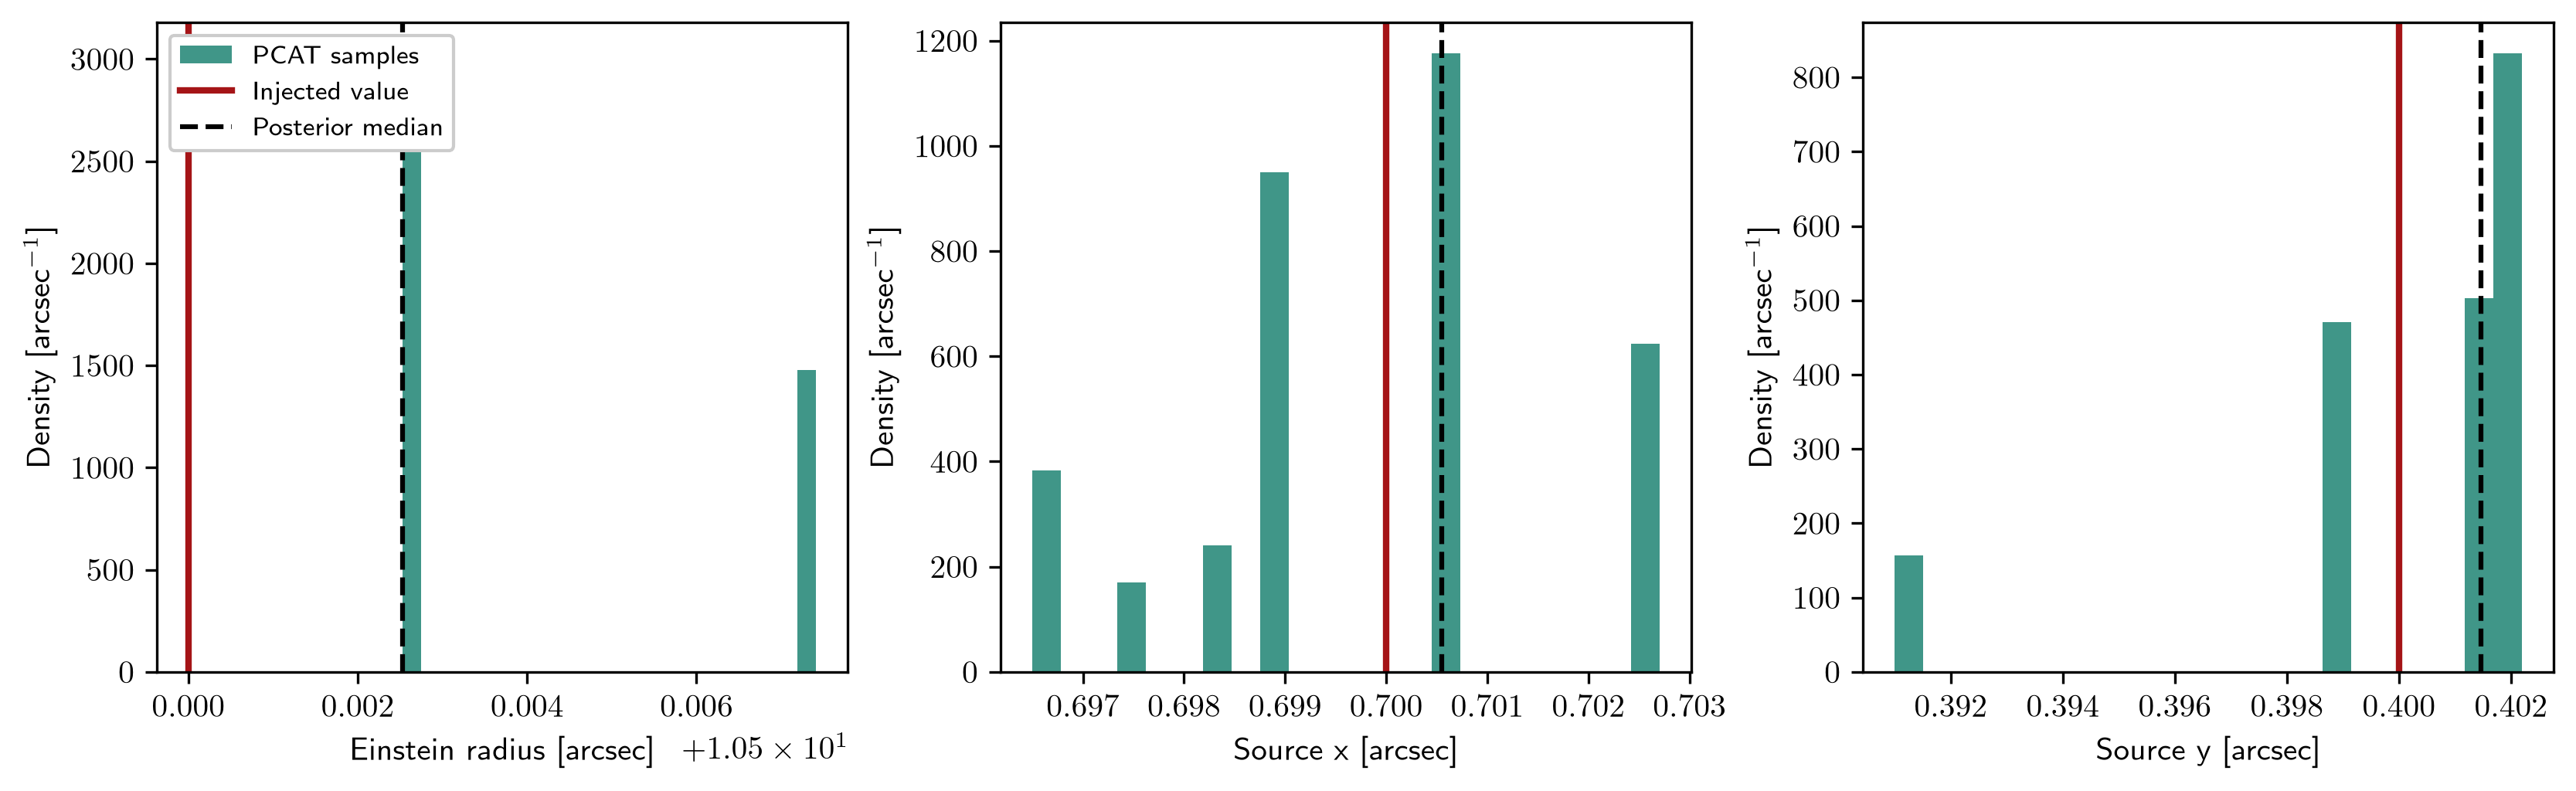

Einstein radius [arcsec]: 10.50 [10.50, 10.51] (16th, 84th percentiles)
Source x [arcsec]: 0.70 [0.70, 0.70] (16th, 84th percentiles)
Source y [arcsec]: 0.40 [0.40, 0.40] (16th, 84th percentiles)


In [4]:
print(f'Reading from {pipeline.parameter_path}...')
display(Image(filename=str(pipeline.parameter_path)))
parameter_labels = ('Einstein radius [arcsec]', 'Source x [arcsec]', 'Source y [arcsec]')
for label, values in zip(parameter_labels, draws.T):
    lower, middle, upper = np.percentile(values, (16, 50, 84))  # [arcsec]
    print(f'{label}: {middle:.2f} [{lower:.2f}, {upper:.2f}] (16th, 84th percentiles)')